In [1]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('/Users/nir/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3
X, Y = [], []
for w in words[:3]:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
C = torch.randn((27,2))
C[X].shape

torch.Size([16, 3, 2])

In [7]:
X[13,2]

tensor(1)

In [8]:
C[X][13,2]

tensor([-1.4030,  0.2761])

In [9]:
C[1]

tensor([-1.4030,  0.2761])

In [10]:
emb = C[X]

W1 = torch.randn((6, 100))
b1 = torch.randn(100)

torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape

torch.Size([16, 6])

In [11]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([16, 6])

In [12]:
emb.view(16, 6).shape

torch.Size([16, 6])

In [13]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [14]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

logits = h @ W2 + b2
logits.shape

torch.Size([16, 27])

In [15]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([16, 27])

In [16]:
loss = -prob[torch.arange(16), Y].log().mean()
loss

tensor(12.8115)

In [17]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [18]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(20.2417)

In [19]:
F.cross_entropy(logits, Y) # calculates max value in logits and subtracts from all logits. well-behaved.
                           # -> pass and <- pass are also more efficient

tensor(20.2417)

In [20]:
lre = torch.linspace(-2, 0, 1000)
lrs = 10**lre

In [21]:
for p in parameters:
    p.requires_grad = True

lri = []
lossi = []
for i in range(1000):
    # minibatch
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    if i < 10 or i > 990:
        print(loss.item())
    if i == 10:
        print('...')
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -lrs[i] * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())

22.639707565307617
18.14716911315918
19.310407638549805
17.078201293945312
15.362189292907715
14.328582763671875
16.13431739807129
14.693036079406738
15.586681365966797
13.787195205688477
...
1.0910849571228027
0.1707472801208496
1.6098045110702515
0.43491920828819275
1.7968261241912842
1.0725326538085938
4.358523845672607
1.705465316772461
0.1508195549249649


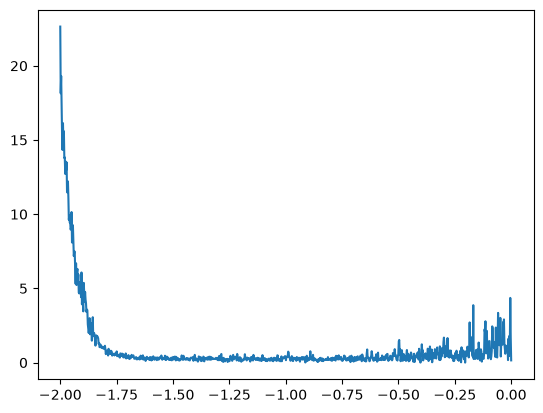

In [22]:
plt.plot(lri, lossi)

In [23]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [24]:
for p in parameters:
    p.requires_grad = True

for i in range(10000):
    # minibatch
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad # implement learning rate decay at the end of training

In [25]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss.item()

0.21452343463897705

In [26]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '->', itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [27]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [28]:
for p in parameters:
    p.requires_grad = True

In [29]:
lossi = []
stepi = []

In [30]:
for i in range(50000):
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad # implement learning rate decay at the end of training

    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

In [31]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.365828514099121

In [32]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.4054324626922607

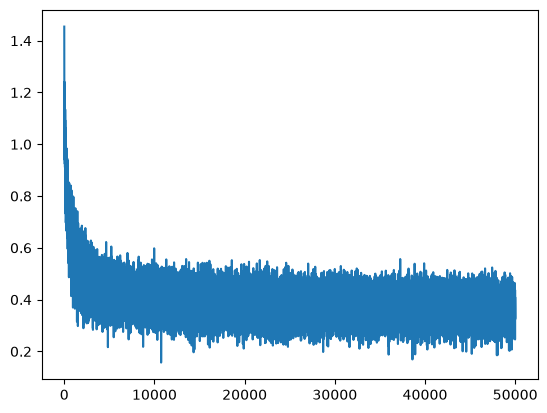

In [33]:
plt.plot(stepi, lossi)

In [34]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

chriah.
aar.
harif.
jore.
rey.
jahnaan.
kebrah.
eva.
merah.
jarqui.
jeroniah.
maiia.
kailin.
dham.
joce.
quint.
sroix.
alia.
brio.
jero.
